Upload your ZIP file containing WAV audio files.


Saving free-spoken-digit-dataset-master.zip to free-spoken-digit-dataset-master.zip

Uploaded file: free-spoken-digit-dataset-master.zip
ZIP file extracted successfully.
Total audio files found: 3000
Audio files used for training: 500

Processing audio files...
Processed 25/500 files
Processed 50/500 files
Processed 75/500 files
Processed 100/500 files
Processed 125/500 files
Processed 150/500 files
Processed 175/500 files
Processed 200/500 files
Processed 225/500 files
Processed 250/500 files
Processed 275/500 files
Processed 300/500 files
Processed 325/500 files
Processed 350/500 files
Processed 375/500 files
Processed 400/500 files
Processed 425/500 files
Processed 450/500 files
Processed 475/500 files
Processed 500/500 files

Dataset preparation completed.
Valid audio files: 500
Feature matrix shape: (98082, 10)
Label vector shape: (98082,)
Silence frames: 75135
Speech frames: 22947

Training samples: 78465
Testing samples: 19617

Training Voice Activity Detection model...
Model tr

,Metric,Score
0,Accuracy,0.973645
1,Precision,0.983614
2,Recall,0.902397
3,F1 Score,0.941257



CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Silence       0.97      1.00      0.98     15027
      Speech       0.98      0.90      0.94      4590

    accuracy                           0.97     19617
   macro avg       0.98      0.95      0.96     19617
weighted avg       0.97      0.97      0.97     19617



<Figure size 600x500 with 0 Axes>

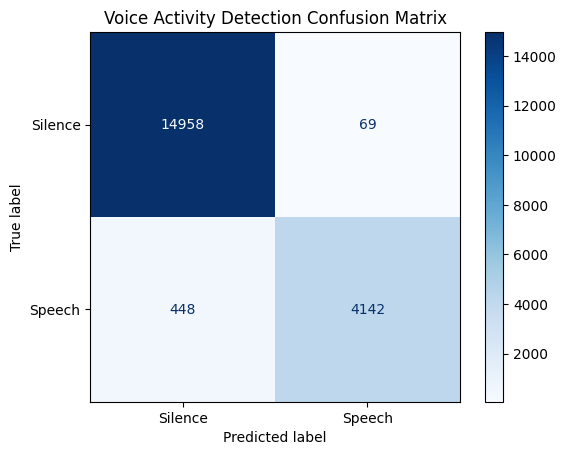

,Feature,Importance
2,Spectral Centroid,0.281796
6,MFCC 2,0.192033
1,Zero Crossing Rate,0.187411
0,RMS Energy,0.107922
4,Spectral Rolloff,0.092211
5,MFCC 1,0.039174
3,Spectral Bandwidth,0.037036
8,MFCC 4,0.023067
7,MFCC 3,0.019859
9,MFCC 5,0.019490


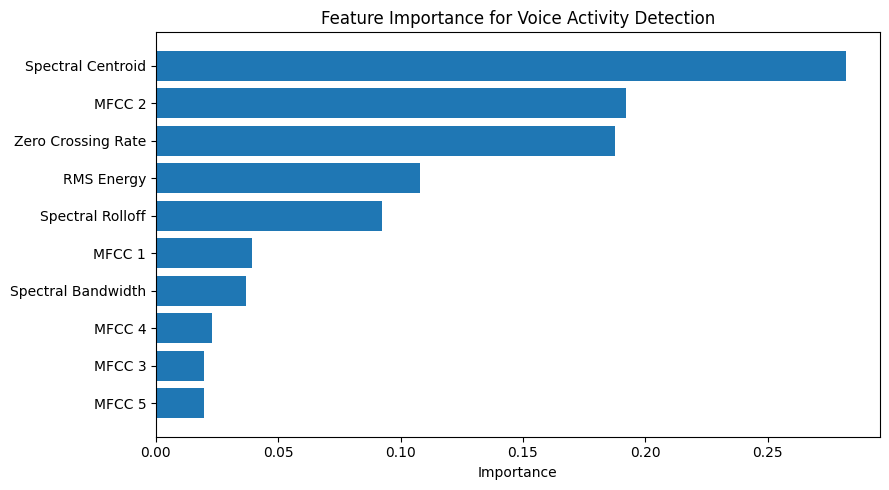


Saved files:
/content/voice_activity_detection_project/model/voice_activity_detector.pkl
/content/voice_activity_detection_project/outputs/model_metrics.csv
/content/voice_activity_detection_project/outputs/feature_importance.csv

DETECTED SPEECH SEGMENTS


,Start Time,End Time,Duration
0,0.0,0.517,0.517


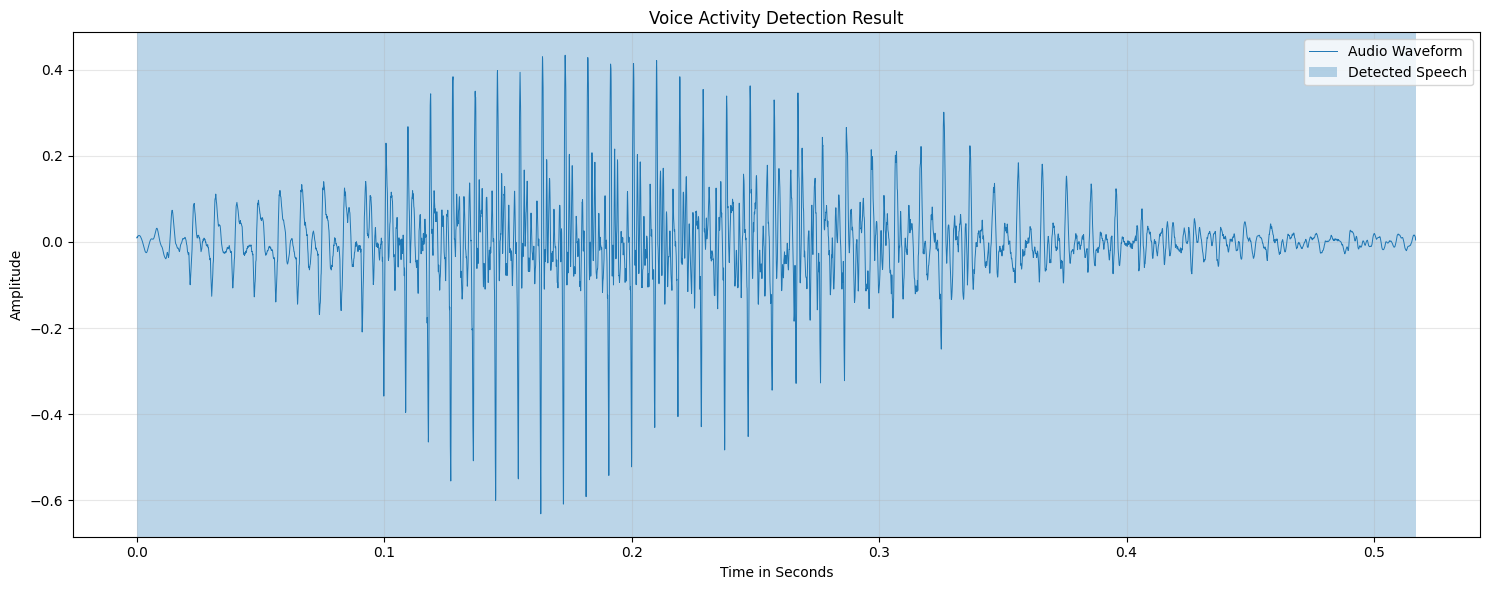


PROJECT COMPLETED SUCCESSFULLY.
Project folder: /content/voice_activity_detection_project
Speech-only audio: /content/voice_activity_detection_project/outputs/speech_only_output.wav
Speech timestamps: /content/voice_activity_detection_project/outputs/speech_segments.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ============================================================
# VOICE ACTIVITY DETECTION PROJECT
# Upload ZIP Dataset -> Train -> Evaluate -> Detect Speech
# ============================================================

!pip -q install librosa soundfile scikit-learn scipy matplotlib pandas joblib

import os
import zipfile
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from google.colab import files
from scipy.signal import medfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================================================
# 1. PROJECT FOLDERS
# ============================================================

PROJECT_DIR = "/content/voice_activity_detection_project"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")

for folder in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(folder, exist_ok=True)

# ============================================================
# 2. UPLOAD ZIP FILE
# ============================================================

print("Upload your ZIP file containing WAV audio files.")
uploaded = files.upload()

if len(uploaded) == 0:
    raise Exception("No ZIP file was uploaded.")

zip_name = list(uploaded.keys())[0]

if not zip_name.lower().endswith(".zip"):
    raise Exception("Please upload a ZIP file.")

zip_path = os.path.join(PROJECT_DIR, zip_name)

with open(zip_path, "wb") as f:
    f.write(uploaded[zip_name])

print(f"\nUploaded file: {zip_name}")

# ============================================================
# 3. EXTRACT ZIP DATASET
# ============================================================

EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("ZIP file extracted successfully.")

# ============================================================
# 4. FIND ALL AUDIO FILES
# ============================================================

audio_files = []

for root, dirs, filenames in os.walk(EXTRACT_DIR):
    for filename in filenames:
        if filename.lower().endswith((".wav", ".mp3", ".flac", ".ogg", ".m4a")):
            audio_files.append(os.path.join(root, filename))

if len(audio_files) == 0:
    raise Exception(
        "No audio files found. Please upload a ZIP containing WAV, MP3, FLAC, OGG, or M4A files."
    )

print(f"Total audio files found: {len(audio_files)}")

# Limit files for a small and fast project
MAX_FILES = min(len(audio_files), 500)
audio_files = audio_files[:MAX_FILES]

print(f"Audio files used for training: {len(audio_files)}")

# ============================================================
# 5. AUDIO AND FEATURE SETTINGS
# ============================================================

SAMPLE_RATE = 16000
FRAME_LENGTH = 400       # 25 milliseconds
HOP_LENGTH = 160         # 10 milliseconds
N_MFCC = 5

# ============================================================
# 6. FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(audio, sr=SAMPLE_RATE):
    """
    Extract frame-level acoustic features.
    Each frame receives one feature vector.
    """

    if len(audio) < FRAME_LENGTH:
        audio = np.pad(
            audio,
            (0, FRAME_LENGTH - len(audio)),
            mode="constant"
        )

    rms = librosa.feature.rms(
        y=audio,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    zcr = librosa.feature.zero_crossing_rate(
        y=audio,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    ).T

    min_len = min(
        len(rms),
        len(zcr),
        len(spectral_centroid),
        len(spectral_bandwidth),
        len(spectral_rolloff),
        len(mfcc)
    )

    features = np.column_stack([
        rms[:min_len],
        zcr[:min_len],
        spectral_centroid[:min_len],
        spectral_bandwidth[:min_len],
        spectral_rolloff[:min_len],
        mfcc[:min_len]
    ])

    return features

# ============================================================
# 7. CREATE SYNTHETIC SPEECH + SILENCE DATA
# ============================================================

def create_speech_silence_sample(audio):
    """
    Creates:
    silence + speech + silence

    Labels:
    0 = silence
    1 = speech
    """

    audio = audio.astype(np.float32)

    # Normalize audio
    max_value = np.max(np.abs(audio))

    if max_value > 0:
        audio = audio / max_value

    # Add silence before and after speech
    silence_before = np.zeros(
        int(np.random.uniform(0.3, 1.2) * SAMPLE_RATE)
    )

    silence_after = np.zeros(
        int(np.random.uniform(0.3, 1.2) * SAMPLE_RATE)
    )

    mixed_audio = np.concatenate([
        silence_before,
        audio,
        silence_after
    ])

    # Optional low-level background noise
    noise_level = np.random.uniform(0.0, 0.008)
    noise = np.random.normal(
        0,
        noise_level,
        len(mixed_audio)
    ).astype(np.float32)

    mixed_audio = mixed_audio + noise

    speech_start = len(silence_before)
    speech_end = speech_start + len(audio)

    features = extract_features(mixed_audio)

    frame_times = np.arange(len(features)) * HOP_LENGTH

    labels = np.zeros(len(features), dtype=int)

    for i, frame_start in enumerate(frame_times):
        frame_end = frame_start + FRAME_LENGTH

        if frame_end >= speech_start and frame_start <= speech_end:
            labels[i] = 1

    # Ensure same number of rows
    min_len = min(len(features), len(labels))

    return (
        features[:min_len],
        labels[:min_len],
        mixed_audio,
        speech_start,
        speech_end
    )

# ============================================================
# 8. LOAD DATASET AND BUILD TRAINING MATRIX
# ============================================================

X_all = []
y_all = []

valid_audio_count = 0

print("\nProcessing audio files...")

for index, audio_path in enumerate(audio_files):

    try:
        audio, sr = librosa.load(
            audio_path,
            sr=SAMPLE_RATE,
            mono=True
        )

        if len(audio) < 1000:
            continue

        features, labels, _, _, _ = create_speech_silence_sample(audio)

        X_all.append(features)
        y_all.append(labels)

        valid_audio_count += 1

        if (index + 1) % 25 == 0:
            print(f"Processed {index + 1}/{len(audio_files)} files")

    except Exception as error:
        print(f"Skipped file: {audio_path}")
        print(f"Reason: {error}")

if len(X_all) == 0:
    raise Exception("No valid audio data could be processed.")

X = np.vstack(X_all)
y = np.concatenate(y_all)

print("\nDataset preparation completed.")
print("Valid audio files:", valid_audio_count)
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Silence frames:", int(np.sum(y == 0)))
print("Speech frames:", int(np.sum(y == 1)))

# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================================
# 10. TRAIN RANDOM FOREST VAD MODEL
# ============================================================

print("\nTraining Voice Activity Detection model...")

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

# ============================================================
# 11. MODEL EVALUATION
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\nMODEL PERFORMANCE")
display(metrics)

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Silence", "Speech"],
        zero_division=0
    )
)

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Silence", "Speech"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Voice Activity Detection Confusion Matrix")
plt.grid(False)
plt.show()

# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

feature_names = [
    "RMS Energy",
    "Zero Crossing Rate",
    "Spectral Centroid",
    "Spectral Bandwidth",
    "Spectral Rolloff",
    "MFCC 1",
    "MFCC 2",
    "MFCC 3",
    "MFCC 4",
    "MFCC 5"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

plt.figure(figsize=(9, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance for Voice Activity Detection")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ============================================================
# 14. SAVE MODEL AND RESULTS
# ============================================================

model_path = os.path.join(
    MODEL_DIR,
    "voice_activity_detector.pkl"
)

joblib.dump(model, model_path)

metrics_path = os.path.join(
    OUTPUT_DIR,
    "model_metrics.csv"
)

importance_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.csv"
)

metrics.to_csv(metrics_path, index=False)
importance_df.to_csv(importance_path, index=False)

print("\nSaved files:")
print(model_path)
print(metrics_path)
print(importance_path)

# ============================================================
# 15. RUN VAD ON ONE AUDIO FILE
# ============================================================

test_audio_path = audio_files[0]

test_audio, test_sr = librosa.load(
    test_audio_path,
    sr=SAMPLE_RATE,
    mono=True
)

test_features = extract_features(test_audio)

frame_predictions = model.predict(test_features)

# Smooth predictions to reduce isolated errors
if len(frame_predictions) >= 5:
    smoothed_predictions = medfilt(
        frame_predictions,
        kernel_size=5
    ).astype(int)
else:
    smoothed_predictions = frame_predictions

# ============================================================
# 16. GENERATE SPEECH TIMESTAMPS
# ============================================================

speech_segments = []

is_speech = False
segment_start = None

for i, prediction in enumerate(smoothed_predictions):

    current_time = i * HOP_LENGTH / SAMPLE_RATE

    if prediction == 1 and not is_speech:
        is_speech = True
        segment_start = current_time

    elif prediction == 0 and is_speech:
        is_speech = False
        segment_end = current_time

        if segment_end - segment_start >= 0.10:
            speech_segments.append({
                "Start Time": round(segment_start, 3),
                "End Time": round(segment_end, 3),
                "Duration": round(segment_end - segment_start, 3)
            })

if is_speech:
    segment_end = len(test_audio) / SAMPLE_RATE

    speech_segments.append({
        "Start Time": round(segment_start, 3),
        "End Time": round(segment_end, 3),
        "Duration": round(segment_end - segment_start, 3)
    })

segments_df = pd.DataFrame(speech_segments)

print("\nDETECTED SPEECH SEGMENTS")

if len(segments_df) > 0:
    display(segments_df)
else:
    print("No speech segments detected.")

segments_path = os.path.join(
    OUTPUT_DIR,
    "speech_segments.csv"
)

segments_df.to_csv(segments_path, index=False)

# ============================================================
# 17. VISUALIZE WAVEFORM AND VAD OUTPUT
# ============================================================

time_axis = np.arange(len(test_audio)) / SAMPLE_RATE

plt.figure(figsize=(15, 6))

plt.plot(
    time_axis,
    test_audio,
    linewidth=0.7,
    label="Audio Waveform"
)

for segment in speech_segments:
    plt.axvspan(
        segment["Start Time"],
        segment["End Time"],
        alpha=0.3,
        label="Detected Speech"
    )

plt.title("Voice Activity Detection Result")
plt.xlabel("Time in Seconds")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 18. SAVE SPEECH-ONLY AUDIO
# ============================================================

speech_audio = np.zeros_like(test_audio)

for segment in speech_segments:

    start_sample = int(
        segment["Start Time"] * SAMPLE_RATE
    )

    end_sample = int(
        segment["End Time"] * SAMPLE_RATE
    )

    speech_audio[start_sample:end_sample] = \
        test_audio[start_sample:end_sample]

speech_only_path = os.path.join(
    OUTPUT_DIR,
    "speech_only_output.wav"
)

sf.write(
    speech_only_path,
    speech_audio,
    SAMPLE_RATE
)

# ============================================================
# 19. SAVE PROJECT SUMMARY
# ============================================================

summary_path = os.path.join(
    OUTPUT_DIR,
    "project_summary.txt"
)

with open(summary_path, "w") as file:
    file.write("VOICE ACTIVITY DETECTION PROJECT\n")
    file.write("=" * 45 + "\n\n")
    file.write(f"Audio files used: {valid_audio_count}\n")
    file.write(f"Training samples: {len(X_train)}\n")
    file.write(f"Testing samples: {len(X_test)}\n")
    file.write(f"Feature count: {X.shape[1]}\n\n")
    file.write(f"Accuracy: {accuracy:.4f}\n")
    file.write(f"Precision: {precision:.4f}\n")
    file.write(f"Recall: {recall:.4f}\n")
    file.write(f"F1 Score: {f1:.4f}\n\n")
    file.write("Classes:\n")
    file.write("0 = Silence\n")
    file.write("1 = Speech\n")

print("\nPROJECT COMPLETED SUCCESSFULLY.")
print("Project folder:", PROJECT_DIR)
print("Speech-only audio:", speech_only_path)
print("Speech timestamps:", segments_path)

# ============================================================
# 20. DOWNLOAD IMPORTANT OUTPUT FILES
# ============================================================

print("\nDownloading trained model...")
files.download(model_path)

print("Downloading speech timestamps...")
files.download(segments_path)

print("Downloading speech-only audio...")
files.download(speech_only_path)